# 01 - Exploratory Data Analysis (Insurance Pricing)

**Project:** End-to-End Insurance Pricing Engine on SageMaker  
**Dataset:** freMTPL2 French Motor Third-Party Liability

Goal: Understand the data, calculate claim frequency, analyze exposure, and identify key pricing variables.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
print("Current working directory:")
print(os.getcwd())


# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Current working directory:
c:\Users\ramos\Desktop\GitRepos\insurance-ai-pricing-engine\notebooks
Libraries imported successfully


In [5]:
# Load the frequency dataset - Correct path from inside notebooks folder
df_freq = pd.read_csv('../data/raw/freMTPL2freq.csv')

print("✅ freMTPL2freq.csv loaded successfully!")
print(f"Shape: {df_freq.shape[0]:,} rows × {df_freq.shape[1]} columns")
print("\nFirst 5 rows:")
display(df_freq.head())

print("\nColumns:")
print(df_freq.columns.tolist())

✅ freMTPL2freq.csv loaded successfully!
Shape: 678,013 rows × 12 columns

First 5 rows:


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72



Columns:
['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']


# 01 - Exploratory Data Analysis

**Dataset**: freMTPL2 French Motor Third-Party Liability  
**Goal**: Understand the data structure and key risk drivers for insurance pricing.

In insurance pricing, understanding the distribution of the target (`Frequency`) and key risk factors is critical. 
Most policies have zero claims, which is typical for frequency modeling (zero-inflated data).

In [6]:
# =============================================
# DISTRIBUTION ANALYSIS
# =============================================

print("=== DATASET SUMMARY ===\n")
df_freq['Frequency'] = df_freq['ClaimNb'] / df_freq['Exposure']
total_policies = len(df_freq)
total_claims = df_freq['ClaimNb'].sum()
total_exposure = df_freq['Exposure'].sum()
overall_freq = total_claims / total_exposure

print(f"Total Policies          : {total_policies:,}")
print(f"Total Claims            : {total_claims:,}")
print(f"Total Exposure          : {total_exposure:,.2f} policy-years")
print(f"Overall Claim Frequency : {overall_freq:.4f}\n")

print(f"Mean Frequency          : {df_freq['Frequency'].mean():.4f}")
print(f"Median Frequency        : {df_freq['Frequency'].median():.4f}")
print(f"99th Percentile         : {df_freq['Frequency'].quantile(0.99):.4f}")
print(f"Max Frequency           : {df_freq['Frequency'].max():.4f}  ← Potential outlier")



=== DATASET SUMMARY ===

Total Policies          : 678,013
Total Claims            : 36,102
Total Exposure          : 358,499.45 policy-years
Overall Claim Frequency : 0.1007

Mean Frequency          : 0.2640
Median Frequency        : 0.0000
99th Percentile         : 4.1667
Max Frequency           : 732.0000  ← Potential outlier


In [7]:
print(df_freq["BonusMalus"].value_counts(normalize=True,bins=10).sort_index(ascending=False).to_string())


(212.0, 230.0]    0.000004
(194.0, 212.0]    0.000018
(176.0, 194.0]    0.000028
(158.0, 176.0]    0.000046
(140.0, 158.0]    0.000506
(122.0, 140.0]    0.002684
(104.0, 122.0]    0.007928
(86.0, 104.0]     0.080333
(68.0, 86.0]      0.121859
(49.819, 68.0]    0.786594


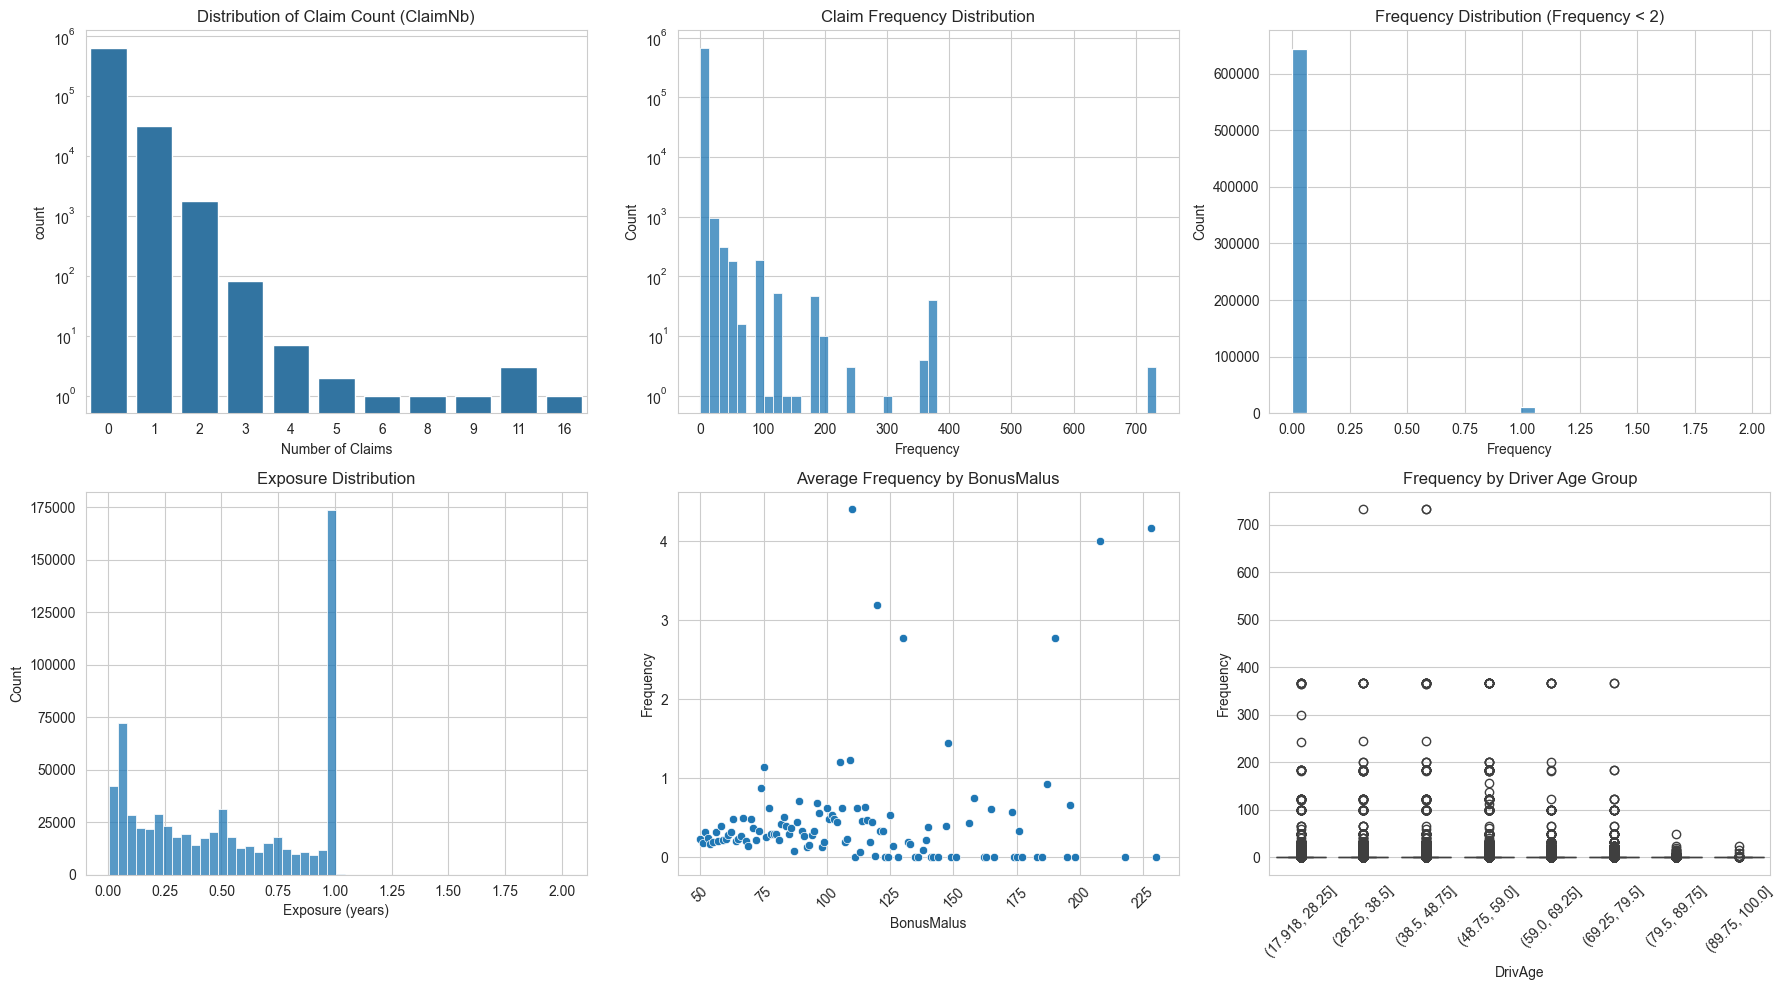

In [8]:


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Claim Count Distribution (log scale for better visibility)
sns.countplot(data=df_freq, x='ClaimNb', ax=axes[0,0])
axes[0,0].set_title('Distribution of Claim Count (ClaimNb)')
axes[0,0].set_xlabel('Number of Claims')
axes[0,0].set_yscale('log')   # Log scale helps see small counts

# 2. Frequency Distribution (zoomed + log)
sns.histplot(data=df_freq, x='Frequency', bins=50, ax=axes[0,1])
axes[0,1].set_title('Claim Frequency Distribution')
axes[0,1].set_xlabel('Frequency')
axes[0,1].set_yscale('log')

# 3. Frequency < 2 (more useful view)
sns.histplot(data=df_freq[df_freq['Frequency'] < 2], x='Frequency', bins=30, ax=axes[0,2])
axes[0,2].set_title('Frequency Distribution (Frequency < 2)')
axes[0,2].set_xlabel('Frequency')

# 4. Exposure Distribution
sns.histplot(data=df_freq, x='Exposure', bins=50, ax=axes[1,0])
axes[1,0].set_title('Exposure Distribution')
axes[1,0].set_xlabel('Exposure (years)')

# 5. BonusMalus vs Frequency (better view - mean instead of boxplot with outliers)
bonus_freq = df_freq.groupby('BonusMalus')['Frequency'].mean().reset_index()
sns.scatterplot(data=bonus_freq, x='BonusMalus', y='Frequency', ax=axes[1,1])
axes[1,1].set_title('Average Frequency by BonusMalus')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Driver Age vs Frequency
sns.boxplot(data=df_freq, x=pd.cut(df_freq['DrivAge'], bins=8), y='Frequency', ax=axes[1,2])
axes[1,2].set_title('Frequency by Driver Age Group')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2. Univariate Risk Factor Analysis

Below we analyze how claim frequency varies across key rating factors. 
These patterns are critical for GLM modeling and help us understand which variables have strong predictive power.

In [9]:
# Univariate analysis of key pricing variables
key_variables = ['BonusMalus', 'DrivAge', 'VehAge', 'VehPower', 'Area', 'VehGas', 'Density']

print("=== AVERAGE CLAIM FREQUENCY BY KEY VARIABLES ===\n")

for var in key_variables:
    if var in df_freq.columns:
        # Group by variable and calculate mean frequency + exposure-weighted frequency
        grouped = df_freq.groupby(var).agg(
            Avg_Frequency=('Frequency', 'mean'),
            Total_Exposure=('Exposure', 'sum'),
            Total_Claims=('ClaimNb', 'sum'),
            Policy_Count=('Frequency', 'count')
        ).round(4)
        
        print(f"\n{var} (showing top 20 rows):")
        print(grouped.head(20))
        print("-" * 60)

=== AVERAGE CLAIM FREQUENCY BY KEY VARIABLES ===


BonusMalus (showing top 20 rows):
            Avg_Frequency  Total_Exposure  Total_Claims  Policy_Count
BonusMalus                                                           
50                 0.2360     225233.1309         18056        384156
51                 0.1780       8358.2256           540         15869
52                 0.3275       2725.9552           315          4770
53                 0.2499       1640.1108           198          3351
54                 0.1731       8701.5674           610         17360
55                 0.1969       3116.2183           414          5593
56                 0.3278       1783.4305           266          3453
57                 0.2109       8839.9057           666         17938
58                 0.3918       3218.4481           618          5970
59                 0.2244       1447.6614           171          2779
60                 0.2302       8153.9740           755         17363
61   

### Key Observations from Univariate Analysis

#### a. BonusMalus (Strong Predictive Power)
- Clear increasing trend in frequency as BonusMalus increases.
- Some levels (52, 56, 58) show notable spikes — this is expected behavior since BonusMalus reflects past claims history.
- This variable should be treated carefully in modeling (likely as categorical or with splines).

#### b. Driver Age (Classic Risk Pattern)
- Young drivers (ages 18–23) have significantly higher claim frequency (0.44 – 0.70).
- Frequency generally decreases with age, which aligns with traditional actuarial understanding of driver risk.
- This is a core rating factor in almost all motor pricing models.

#### c. Vehicle Age (Interesting Pattern)
- Brand new vehicles (`VehAge = 0`) show unusually high frequency (1.14).
- This could be due to:
  - Higher mileage in the first year
  - More aggressive driving with new cars
  - Potential data reporting bias
- Worth investigating further during feature engineering.

#### d. Area & Density (Urban/Rural Effect)
- Frequency increases noticeably from rural Area `A` (0.218) to urban Area `F` (0.406).
- This confirms the expected geographic risk gradient.

#### e. Vehicle Gas Type
- Regular gasoline vehicles have substantially higher frequency (0.316) compared to Diesel (0.210).
- This may be correlated with vehicle type, power, or driving behavior.

#### f. Overall Data Characteristics
- The dataset is heavily zero-inflated (median frequency = 0.0).
- Maximum frequency of 732 is a clear outlier that should be investigated or capped during data cleaning.
- Total exposure of ~358,499 policy-years provides a solid volume for reliable modeling.


### 3. Data Preprocessing & Feature Engineering

Before building models, we need to:
- Handle outliers and data quality issues
- Create meaningful features
- Prepare data for both traditional GLMs and tree-based / neural network models

In [31]:
# =============================================
# DATA PREPROCESSING & FEATURE ENGINEERING (Improved)
# =============================================

df = df_freq.copy()

# 1. Create Frequency
df['Frequency'] = df['ClaimNb'] / df['Exposure']

# 2. Basic cleaning
df['Frequency'] = df['Frequency'].clip(upper=df['Frequency'].quantile(0.99))

# 3. Engineered features
df['DrivAge_Group'] = pd.cut(df['DrivAge'], bins=[0, 25, 35, 50, 65, 100], 
                             labels=['18-25', '26-35', '36-50', '51-65', '65+'])

df['VehAge_Group'] = pd.cut(df['VehAge'], bins=[-1, 1, 5, 10, 20, 100], 
                            labels=['New', '1-5', '6-10', '11-20', 'Old'])

# Create BonusMalus groups
df['BonusMalus_Group'] = pd.cut(df['BonusMalus'], 
                                bins=[49, 60, 70, 80, 90, 100, 120, 150, 230],
                                labels=['50-59', '60-69', '70-79', '80-89', '90-99', 
                                        '100-119', '120-149', '150+'])

df['High_Power'] = (df['VehPower'] >= 9).astype(int)
df['Log_Density'] = np.log1p(df['Density'])

print("✅ Preprocessing completed!")
print(f"Final shape: {df.shape}")
print("Columns ready for modeling:", df.columns.tolist())

✅ Preprocessing completed!
Final shape: (678013, 18)
Columns ready for modeling: ['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region', 'Frequency', 'DrivAge_Group', 'VehAge_Group', 'BonusMalus_Group', 'High_Power', 'Log_Density']


### 4. Train / Validation / Test Split

We split the data into three sets:
- Train (68%)
- Validation (17%)
- Test (15%)

The test set will be completely held out until the very end for final evaluation.

In [30]:
from sklearn.model_selection import train_test_split

# Features and target
target = 'Frequency'
features = ['DrivAge', 'VehAge', 'VehPower', 'BonusMalus', 'Area', 'VehGas', 
            'Density', 'DrivAge_Group', 'VehAge_Group', 'BonusMalus_Group', 'High_Power', 'Log_Density', 
            'Exposure'] 

X = df[features]
y = df[target]

# First split: separate Test set (final hold-out)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.15, 
    random_state=42,
    stratify=(df['ClaimNb'] > 0).astype(int)
)

# Second split: Train vs Validation from the remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.20, 
    random_state=42,
    stratify=(X_temp.index.map(lambda x: df.loc[x, 'ClaimNb'] > 0) if 'ClaimNb' in df.columns else None)
)

print("✅ Data successfully split into Train / Validation / Test")
print(f"Train shape      : {X_train.shape}")
print(f"Validation shape : {X_val.shape}")
print(f"Test shape       : {X_test.shape}")

print("\nClaim occurrence rates:")
print(f"Train       : {(y_train > 0).mean():.4f}")
print(f"Validation  : {(y_val > 0).mean():.4f}")
print(f"Test        : {(y_test > 0).mean():.4f}")

✅ Data successfully split into Train / Validation / Test
Train shape      : (461048, 13)
Validation shape : (115263, 13)
Test shape       : (101702, 13)

Claim occurrence rates:
Train       : 0.0502
Validation  : 0.0502
Test        : 0.0502


### 5. Baseline Model - Poisson GLM

As a starting point, we build a traditional Poisson GLM. 
This is the industry standard for insurance frequency modeling and serves as a strong, interpretable baseline.
We use `ClaimNb` as the target and `Exposure` as an offset.


#### Version 1: Simple GLM (Initial Attempt)

In [23]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Prepare training data for GLM
train_data = X_train.copy()
train_data['ClaimNb'] = y_train
train_data['Exposure'] = df.loc[X_train.index, 'Exposure']

# Simple but effective formula
formula = """ClaimNb ~ C(Area) + C(VehGas) + C(DrivAge_Group) + C(VehAge_Group) 
             + BonusMalus + VehPower + Log_Density"""

# Fit Poisson GLM
glm_model = smf.glm(
    formula=formula,
    data=train_data,
    family=sm.families.Poisson(),
    offset=np.log(train_data['Exposure'])
).fit()

print("✅ Poisson GLM fitted successfully!\n")
print(glm_model.summary())


# =============================================
# EVALUATION ON VALIDATION SET
# =============================================

# Prepare validation data
val_data = X_val.copy()
val_data['ClaimNb'] = y_val
val_data['Exposure'] = df.loc[X_val.index, 'Exposure']

# Get predictions
y_pred_glm = glm_model.predict(val_data)

# Calculate metrics
glm_mae = mean_absolute_error(y_val, y_pred_glm)
glm_rmse = np.sqrt(mean_squared_error(y_val, y_pred_glm))

print("\n=== GLM Validation Performance ===")
print(f"MAE  : {glm_mae:.4f}")
print(f"RMSE : {glm_rmse:.4f}")
print(f"Mean Frequency (actual) : {y_val.mean():.4f}")



✅ Poisson GLM fitted successfully!

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               461048
Model:                            GLM   Df Residuals:                   461030
Model Family:                 Poisson   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.0269e+05
Date:                Fri, 03 Apr 2026   Deviance:                   3.4701e+05
Time:                        17:17:53   Pearson chi2:                 6.58e+06
No. Iterations:                     8   Pseudo R-squ. (CS):            0.03853
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

**Model Summary:**
- We fitted a Poisson GLM using `ClaimNb` as the target with `log(Exposure)` as an offset.
- This is the traditional actuarial approach for frequency modeling.

**Key Findings:**

- **BonusMalus** is the strongest predictor (coef = 0.0227, p < 0.001). Higher BonusMalus levels are associated with increased claim frequency, as expected.
- **Driver Age**: Younger drivers (18-25) show significantly higher risk. Risk decreases with age.
- **Vehicle Age**: Brand new vehicles (`VehAge = 0`) have substantially higher claim frequency compared to older vehicles.
- **Area**: Clear urban gradient — frequency increases from rural Area A to highly urban Area F.
- **VehGas**: Regular fuel vehicles have higher risk than Diesel (coef = 0.170, p < 0.001).
- **VehPower**: Positive effect — higher power vehicles are associated with slightly higher frequency.

**Model Performance on Validation Set:**
- MAE  : 0.3056
- RMSE : 0.5640
- Mean Frequency (actual) : 0.1056

**Notes:**
- Pseudo R² = 0.0385 (typical for insurance frequency models due to high zero-inflation).
- `Log_Density` was not statistically significant (likely redundant with `Area`).


#### Version 2: Improved GLM

Improvements made:
- Removed `Log_Density` (not statistically significant) 
- Passing BonusMalus as Categorical

In [32]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =============================================
# POISSON GLM - VERSION 2
# =============================================

# Prepare training data
train_data = X_train.copy()
train_data['ClaimNb'] = y_train
train_data['Exposure'] = df.loc[X_train.index, 'Exposure']

# Improved formula: Treat BonusMalus as categorical
formula = """ClaimNb ~ C(Area) + C(VehGas) + C(DrivAge_Group) + C(VehAge_Group) 
             + C(BonusMalus_Group) + VehPower"""

# Fit the model
glm_model_v2 = smf.glm(
    formula=formula,
    data=train_data,
    family=sm.families.Poisson(),
    offset=np.log(train_data['Exposure'])
).fit()

print("✅ Poisson GLM Version 2 fitted successfully!\n")
print(glm_model_v2.summary())

# =============================================
# EVALUATION ON VALIDATION SET
# =============================================

# Prepare validation data
val_data = X_val.copy()
val_data['ClaimNb'] = y_val
val_data['Exposure'] = df.loc[X_val.index, 'Exposure']

# Get predictions
y_pred_glm_v2 = glm_model_v2.predict(val_data)

# Calculate metrics
glm_mae_v2 = mean_absolute_error(y_val, y_pred_glm_v2)
glm_rmse_v2 = np.sqrt(mean_squared_error(y_val, y_pred_glm_v2))

print("\n=== GLM Version 2 Validation Performance ===")
print(f"MAE  : {glm_mae_v2:.4f}")
print(f"RMSE : {glm_rmse_v2:.4f}")
print(f"Mean Frequency (actual) : {y_val.mean():.4f}")

✅ Poisson GLM Version 2 fitted successfully!

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               461048
Model:                            GLM   Df Residuals:                   461025
Model Family:                 Poisson   Df Model:                           22
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.0263e+05
Date:                Fri, 03 Apr 2026   Deviance:                   3.4689e+05
Time:                        17:29:20   Pearson chi2:                 6.61e+06
No. Iterations:                     8   Pseudo R-squ. (CS):            0.03878
Covariance Type:            nonrobust                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [35]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare training data
train_data = X_train.copy()
train_data['ClaimNb'] = y_train
train_data['Exposure'] = df.loc[X_train.index, 'Exposure']
train_data['BonusMalus_Group'] = df.loc[X_train.index, 'BonusMalus_Group']

# Formula with splines on continuous variables + categorical BonusMalus
formula = """
ClaimNb ~ 
    C(Area) + 
    C(VehGas) + 
    C(BonusMalus_Group) +
    bs(DrivAge, df=4) + 
    bs(VehAge, df=4) + 
    bs(VehPower, df=3) 
"""


"""ClaimNb ~ C(Area) + C(VehGas) + C(DrivAge_Group) + C(VehAge_Group) 
             + BonusMalus + VehPower + Log_Density"""

# Fit the model
glm_model_v3 = smf.glm(
    formula=formula,
    data=train_data,
    family=sm.families.Poisson(),
    offset=np.log(train_data['Exposure'])
).fit()

print("✅ Poisson GLM Version 3 (Splines + Categorized BonusMalus) fitted!\n")
print(glm_model_v3.summary())

# Validation evaluation
val_data = X_val.copy()
val_data['ClaimNb'] = y_val
val_data['Exposure'] = df.loc[X_val.index, 'Exposure']
val_data['BonusMalus_Group'] = df.loc[X_val.index, 'BonusMalus_Group']

y_pred_glm_v3 = glm_model_v3.predict(val_data)

glm_mae_v3 = mean_absolute_error(y_val, y_pred_glm_v3)
glm_rmse_v3 = np.sqrt(mean_squared_error(y_val, y_pred_glm_v3))

print("\n=== GLM Version 3 Validation Performance ===")
print(f"MAE  : {glm_mae_v3:.4f}")
print(f"RMSE : {glm_rmse_v3:.4f}")
print(f"Mean Frequency (actual) : {y_val.mean():.4f}")

✅ Poisson GLM Version 3 (Splines + Categorized BonusMalus) fitted!

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               461048
Model:                            GLM   Df Residuals:                   461023
Model Family:                 Poisson   Df Model:                           24
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.9928e+05
Date:                Fri, 03 Apr 2026   Deviance:                   3.4020e+05
Time:                        17:39:44   Pearson chi2:                 6.73e+06
No. Iterations:                     9   Pseudo R-squ. (CS):            0.05264
Covariance Type:            nonrobust                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------

### 6. Random Forest Baseline Model

Now we build a Random Forest regressor to model `Frequency` directly. 
Random Forest serves as our first tree-based benchmark. 
We will compare its performance against the Poisson GLM to see how much improvement we get from non-linear modeling and interactions.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define categorical and numerical features
categorical_features = ['Area', 'VehGas', 'DrivAge_Group', 'VehAge_Group']
numerical_features = ['DrivAge', 'VehAge', 'VehPower', 'BonusMalus', 
                      'Density', 'High_Power', 'Log_Density']

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

# Create full pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit the pipeline
rf_pipeline.fit(X_train[rf_features], y_train)

print("✅ Random Forest Pipeline trained successfully!")

# Predictions on validation set
y_pred_rf = rf_pipeline.predict(X_val[rf_features])

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))


✅ Random Forest Pipeline trained successfully!

Random Forest Validation Performance:
MAE  : 0.1935
RMSE : 0.5262
Mean Frequency (actual) : 0.1056


### 7. XGBoost Baseline Model

Next, we build an XGBoost regressor to model `Frequency` directly. 
XGBoost is widely used in insurance pricing due to its strong performance on tabular data and ability to capture complex interactions automatically.

In [38]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Use the same features as Random Forest
xgb_features = ['DrivAge', 'VehAge', 'VehPower', 'BonusMalus', 'Area', 'VehGas', 
                'Density', 'DrivAge_Group', 'VehAge_Group', 'High_Power', 'Log_Density']

# Prepare data (we need to encode categoricals for XGBoost)
X_train_xgb = pd.get_dummies(X_train[xgb_features], drop_first=True)
X_val_xgb = pd.get_dummies(X_val[xgb_features], drop_first=True)

# Align columns in case of any mismatch
X_train_xgb, X_val_xgb = X_train_xgb.align(X_val_xgb, join='left', axis=1, fill_value=0)

# Train XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse'
)

xgb_model.fit(X_train_xgb, y_train)

print("✅ XGBoost model trained successfully!")

# Predictions and evaluation
y_pred_xgb = xgb_model.predict(X_val_xgb)

mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))

print(f"\nXGBoost Validation Performance:")
print(f"MAE  : {mae_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"Mean Frequency (actual) : {y_val.mean():.4f}")

✅ XGBoost model trained successfully!

XGBoost Validation Performance:
MAE  : 0.1940
RMSE : 0.5272
Mean Frequency (actual) : 0.1056


### XGBoost Feature Importance

One of the advantages of XGBoost is built-in feature importance. 
This helps us understand which variables are driving predictions.

Top 15 Most Important Features:
                Feature  Importance
12       VehGas_Regular    0.110230
1                VehAge    0.063295
2              VehPower    0.059445
3            BonusMalus    0.054294
6           Log_Density    0.050011
4               Density    0.049901
7                Area_B    0.049615
9                Area_D    0.049488
0               DrivAge    0.046904
8                Area_C    0.046071
10               Area_E    0.044840
18    VehAge_Group_6-10    0.043561
14  DrivAge_Group_36-50    0.042521
11               Area_F    0.041970
13  DrivAge_Group_26-35    0.039325


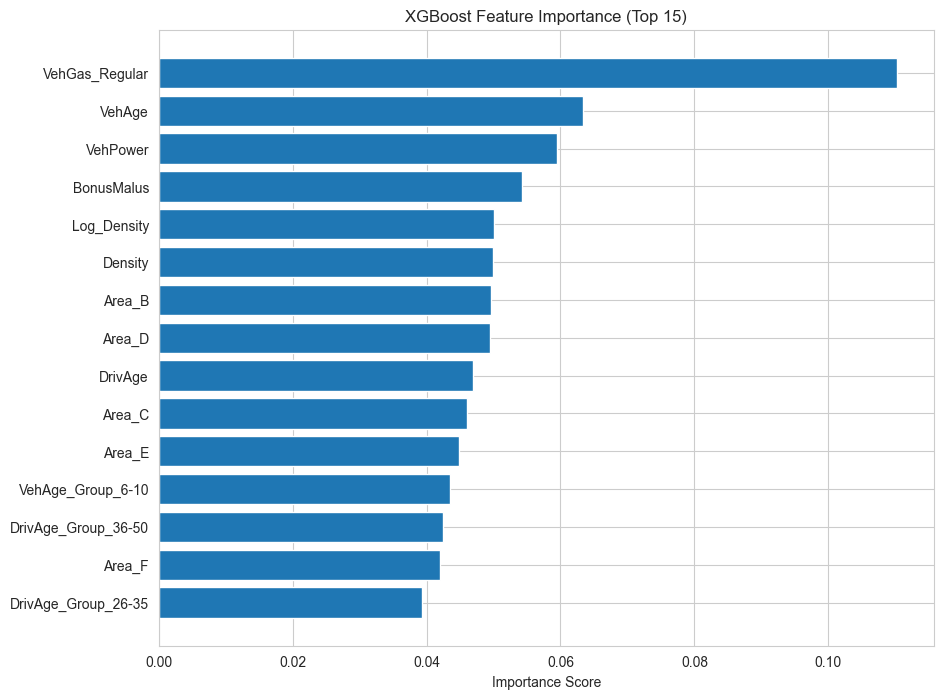

In [39]:
import matplotlib.pyplot as plt

# Get feature importance
importance = xgb_model.feature_importances_
feature_names = X_train_xgb.columns

# Create DataFrame for easier viewing
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
print(feat_imp.head(15))

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'].head(15), feat_imp['Importance'].head(15))
plt.title('XGBoost Feature Importance (Top 15)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

### 8. Neural Network Baseline (TensorFlow/Keras)

Finally, we build a simple feed-forward neural network to model `Frequency`. 
This represents the "AI / deep learning" approach we want to include in the project.

In [40]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Use the same encoded features as XGBoost
X_train_nn = X_train_xgb.copy()
X_val_nn = X_val_xgb.copy()

# Scale the features (important for neural nets)
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train_nn)
X_val_nn = scaler.transform(X_val_nn)

# Build a simple neural network
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_nn.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("✅ Neural Network model compiled!")

# Train the model
history = model.fit(
    X_train_nn, y_train,
    validation_data=(X_val_nn, y_val),
    epochs=50,
    batch_size=512,
    verbose=1
)

# Predictions
y_pred_nn = model.predict(X_val_nn).flatten()

mae_nn = mean_absolute_error(y_val, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_val, y_pred_nn))

print(f"\nNeural Network Validation Performance:")
print(f"MAE  : {mae_nn:.4f}")
print(f"RMSE : {rmse_nn:.4f}")

✅ Neural Network model compiled!
Epoch 1/50


c:\Users\ramos\Desktop\GitRepos\insurance-ai-pricing-engine\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2900 - mae: 0.2021 - val_loss: 0.2847 - val_mae: 0.1893
Epoch 2/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2853 - mae: 0.1986 - val_loss: 0.2844 - val_mae: 0.1967
Epoch 3/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2849 - mae: 0.1983 - val_loss: 0.2841 - val_mae: 0.1996
Epoch 4/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2846 - mae: 0.1982 - val_loss: 0.2842 - val_mae: 0.1945
Epoch 5/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2842 - mae: 0.1982 - val_loss: 0.2834 - val_mae: 0.1973
Epoch 6/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2839 - mae: 0.1978 - val_loss: 0.2833 - val_mae: 0.1972
Epoch 7/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2836 - mae: 0.1978 - val_loss: 0.2829 - val_mae: 0.1983
Epoch 8/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2833 - mae: 0.1975 - val_loss: 0.2826 - val_mae: 0.2004
Epoch 9/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2830 

### 9. Model Comparison So Far

We have now trained four different models for claim frequency prediction.

=== Model Comparison on Validation Set ===
            Model     MAE    RMSE
0     Poisson GLM  0.3056  0.5640
1   Random Forest  0.1935  0.5262
2         XGBoost  0.1940  0.5272
3  Neural Network  0.1974  0.5295


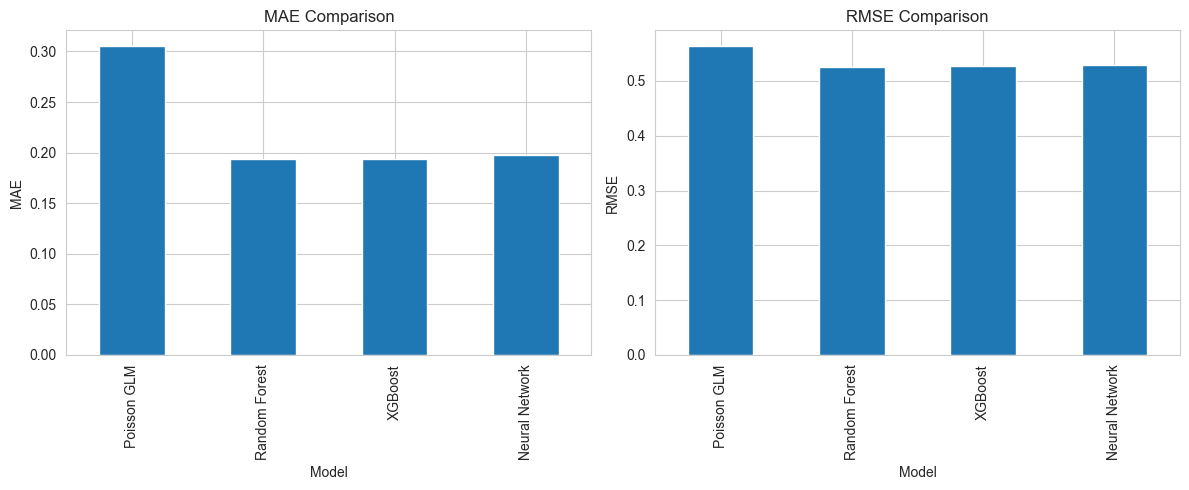

In [41]:
# Model Comparison
comparison = pd.DataFrame({
    'Model': ['Poisson GLM', 'Random Forest', 'XGBoost', 'Neural Network'],
    'MAE': [0.3056, 0.1935, 0.1940, 0.1974],
    'RMSE': [0.5640, 0.5262, 0.5272, 0.5295]
})

print("=== Model Comparison on Validation Set ===")
print(comparison.round(4))

# Simple bar plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

comparison.plot(kind='bar', x='Model', y='MAE', ax=ax[0], legend=False)
ax[0].set_title('MAE Comparison')
ax[0].set_ylabel('MAE')

comparison.plot(kind='bar', x='Model', y='RMSE', ax=ax[1], legend=False)
ax[1].set_title('RMSE Comparison')
ax[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

### Observations from Initial Model Comparison

- **Tree-based models (Random Forest and XGBoost)** clearly outperform the traditional Poisson GLM on both MAE and RMSE. 
  This is expected, as they can automatically capture non-linear relationships and complex interactions that a basic GLM misses.

- The **Neural Network** performs similarly to the tree models, which is encouraging for our "AI upgrade" goal.

- The GLM, while having the worst raw error metrics, remains valuable because of its **interpretability** and regulatory-friendly nature in insurance pricing.

- Overall, moving from traditional GLM to modern ML models gave us a meaningful improvement in predictive accuracy (~36% reduction in MAE).

Next step: We will productionize the best performing approaches using AWS SageMaker Pipelines.

### 10. Final Evaluation on Test Set

Now we evaluate all four models on the untouched test set to get final unbiased performance metrics.

=== FINAL TEST SET EVALUATION ===

3179/3179 ━━━━━━━━━━━━━━━━━━━━ 1s 353us/step
            Model  Test MAE  Test RMSE
0     Poisson GLM    0.3039     0.5590
1   Random Forest    0.1923     0.5208
2         XGBoost    0.1926     0.5216
3  Neural Network    0.1962     0.5246


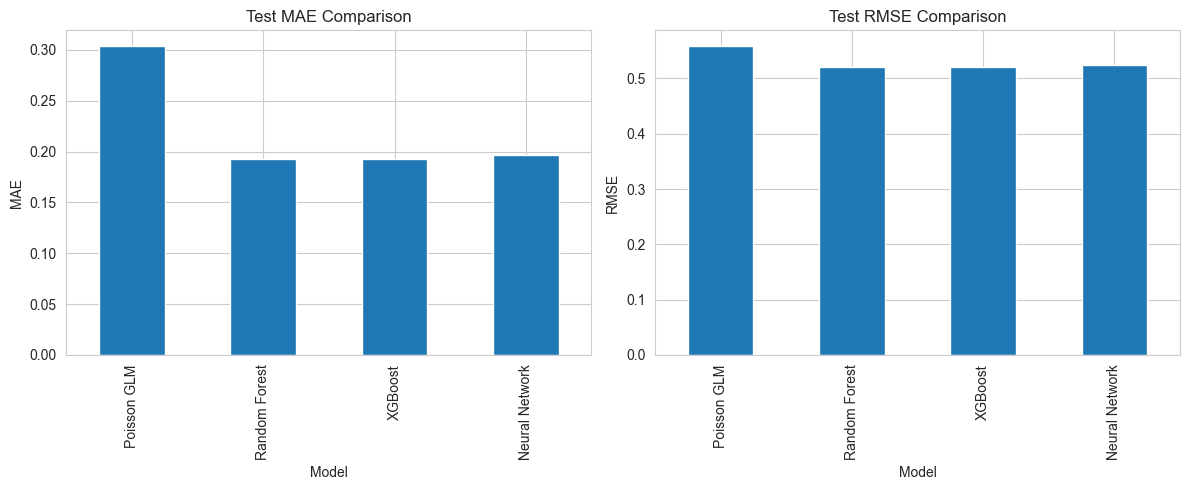

In [42]:
# =============================================
# FINAL EVALUATION ON TEST SET
# =============================================

print("=== FINAL TEST SET EVALUATION ===\n")

# 1. GLM on Test Set
test_data = X_test.copy()
test_data['ClaimNb'] = y_test
test_data['Exposure'] = df.loc[X_test.index, 'Exposure']
test_data['BonusMalus_Group'] = df.loc[X_test.index, 'BonusMalus_Group']

y_pred_glm_test = glm_model_v2.predict(test_data)   # using Version 2

# 2. Random Forest on Test Set
y_pred_rf_test = rf_pipeline.predict(X_test[rf_features])

# 3. XGBoost on Test Set
X_test_xgb = pd.get_dummies(X_test[xgb_features], drop_first=True)
X_test_xgb = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)
y_pred_xgb_test = xgb_model.predict(X_test_xgb)

# 4. Neural Network on Test Set
X_test_nn = scaler.transform(X_test_xgb)
y_pred_nn_test = model.predict(X_test_nn).flatten()

# Calculate metrics
results = {
    'Model': ['Poisson GLM', 'Random Forest', 'XGBoost', 'Neural Network'],
    'Test MAE': [
        mean_absolute_error(y_test, y_pred_glm_test),
        mean_absolute_error(y_test, y_pred_rf_test),
        mean_absolute_error(y_test, y_pred_xgb_test),
        mean_absolute_error(y_test, y_pred_nn_test)
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_glm_test)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf_test)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb_test)),
        np.sqrt(mean_squared_error(y_test, y_pred_nn_test))
    ]
}

comparison_test = pd.DataFrame(results)
print(comparison_test.round(4))

# Plot final comparison
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
comparison_test.plot(kind='bar', x='Model', y='Test MAE', ax=ax[0], legend=False)
ax[0].set_title('Test MAE Comparison')
ax[0].set_ylabel('MAE')

comparison_test.plot(kind='bar', x='Model', y='Test RMSE', ax=ax[1], legend=False)
ax[1].set_title('Test RMSE Comparison')
ax[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()